In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Adjust the path to the current directory where the downloaded files are located
DATA_DIR = Path("../data")

try:
    characters = pd.read_csv(DATA_DIR / "Characters.csv", delimiter=';')
    hp1 = pd.read_csv(DATA_DIR / "Harry Potter 1.csv", delimiter=';')
    hp2 = pd.read_csv(DATA_DIR / "Harry Potter 2.csv", delimiter=';')
    hp3 = pd.read_csv(DATA_DIR / "Harry Potter 3.csv", delimiter=';')
    spells = pd.read_csv(DATA_DIR / "Spells.csv", delimiter=';')
    print('Datasets successfully loaded from the root directory.')

    # Initial quantification after successful load
    print(f'Records in characters: {len(characters)}')
    print(f'Total initial dialogues (HP1+HP2+HP3): {len(hp1)+len(hp2)+len(hp3)}')
except FileNotFoundError as e:
    print(f'Error: File {e.filename} not found. Make sure you have executed the GitHub download.')

Datasets successfully loaded from the root directory.
Records in characters: 140
Total initial dialogues (HP1+HP2+HP3): 4925


Actualización de Metodología:

Vectorización: Los bucles manuales for se reemplazaron con métodos de cadenas integrados de Pandas y explode(). Esto reduce el tiempo de ejecución y sigue los estándares profesionales de ciencia de datos.
Cuantificación: Al expandir la columna 'Loyalty', contabilizamos personajes con múltiples facciones sin perder información en cadenas complejas.
Observaciones Clave:

El análisis de frecuencia de hechizos resalta qué encantamientos forman parte del vocabulario narrativo central.
La distribución de facciones revela la estructura organizacional del mundo mágico en los primeros tres libros, identificando centros de poder más allá de las Casas de Hogwarts.

In [23]:
# Info and null values of characters dataset
characters.info()
characters.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            140 non-null    int64
 1   Name          140 non-null    str  
 2   Gender        139 non-null    str  
 3   Job           121 non-null    str  
 4   House         101 non-null    str  
 5   Wand          132 non-null    str  
 6   Patronus      123 non-null    str  
 7   Species       140 non-null    str  
 8   Blood status  123 non-null    str  
 9   Hair colour   123 non-null    str  
 10  Eye colour    86 non-null     str  
 11  Loyalty       89 non-null     str  
 12  Skills        113 non-null    str  
 13  Birth         127 non-null    str  
 14  Death         42 non-null     str  
dtypes: int64(1), str(14)
memory usage: 16.5 KB


Id               0
Name             0
Gender           1
Job             19
House           39
Wand             8
Patronus        17
Species          0
Blood status    17
Hair colour     17
Eye colour      54
Loyalty         51
Skills          27
Birth           13
Death           98
dtype: int64

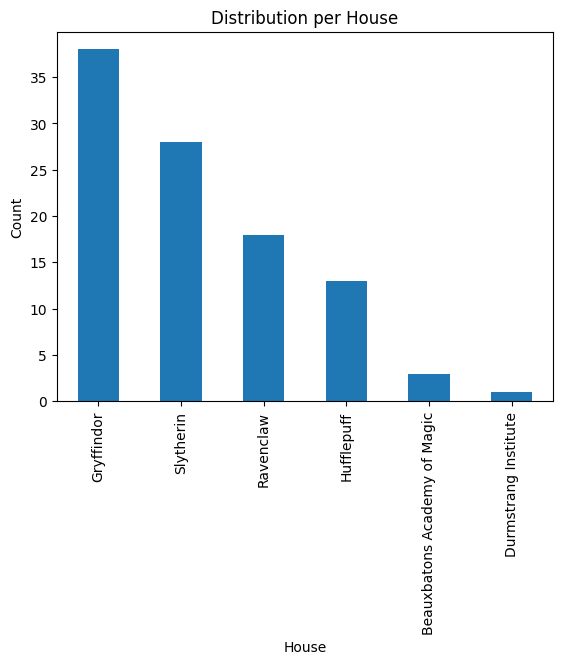

In [24]:
# Distribution per House

characters["House"].value_counts().plot(kind="bar")
plt.title("Distribution per House")
plt.xlabel("House")
plt.ylabel("Count")
plt.show()

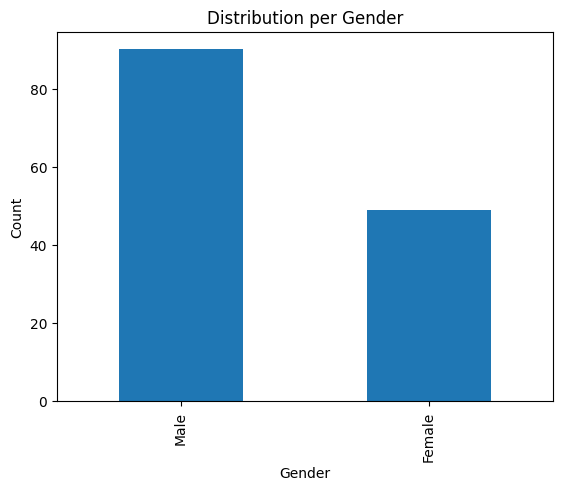

In [25]:
# Distribution per Gender

characters["Gender"].value_counts().plot(kind="bar")
plt.title("Distribution per Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [26]:
#Merging sentences datasets for further evaluation

# Rename HP3's columns
hp3 = hp3.rename(columns={"CHARACTER": "Character", "SENTENCE": "Sentence"})

# Eliminate blank spaces and make uppercase
hp1['Character'] = hp1['Character'].str.upper().str.strip()
hp2['Character'] = hp2['Character'].str.upper().str.strip()
hp3['Character'] = hp3['Character'].str.upper().str.strip()

hp2 = hp2[['Character', 'Sentence']]
hp3 = hp3[['Character', 'Sentence']]

# Concat everything
hp_all = pd.concat([hp1, hp2, hp3], ignore_index=True)

# Replace 'RON' with 'RONALD' in Character column
hp_all.loc[hp_all['Character'] == 'RON', 'Character'] = 'RONALD'
hp_all.loc[hp_all['Character'] == 'MRS. WEASLEY', 'Character'] = 'MOLLY WEASLEY'

print('All sentences shape:', hp_all.shape)

All sentences shape: (4925, 2)


Estrategia:

Normalizamos los nombres de los personajes a mayúsculas y eliminamos espacios.
Concatenamos los tres libros en un solo DataFrame (hp_all).
Preparamos una clave de unión simplificada (First_Name) para mitigar la pérdida de datos durante el merge.

Análisis Multivariable: Diálogos vs. Atributos de Personaje
Hipótesis: La casa de pertenencia determina el volumen narrativo. Realizamos un Left Join optimizado para cuantificar la participación por Casa de Hogwarts.

--- Data Quality Report ---
Lines linked to a House: 2433 (49.40%)


C:\Users\manue\AppData\Local\Temp\ipykernel_24472\2663656409.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_analysis.dropna(subset=['House']).groupby('House')['Line_Count'].sum().reset_index().sort_values('Line_Count', ascending=False),


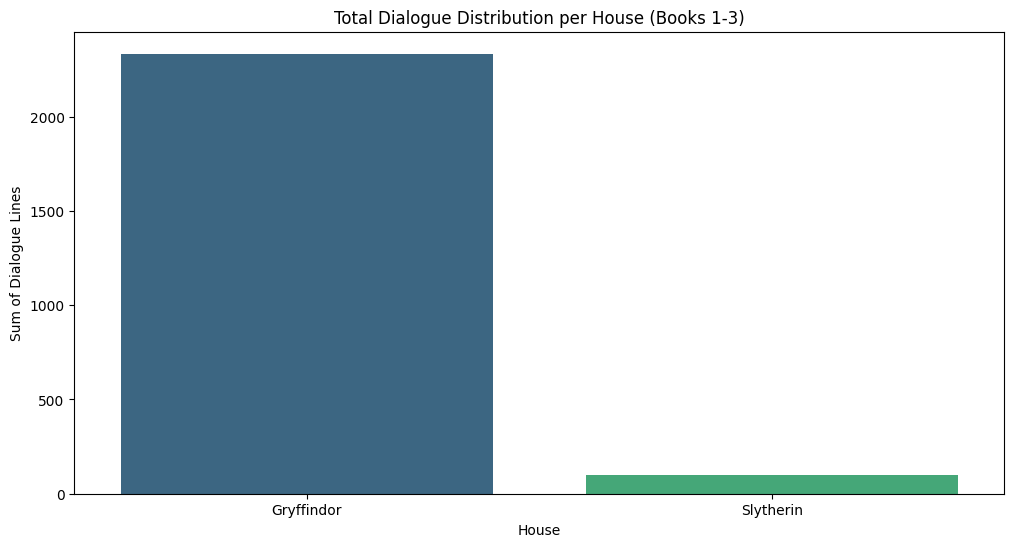

In [27]:
# Prepare join key in metadata (Using first name to avoid data loss)
characters['First_Name_Key'] = characters['Name'].str.split().str[0].str.upper()

# Line aggregation per character
lines_per_character = hp_all['Character'].value_counts().reset_index()
lines_per_character.columns = ['Character', 'Line_Count']

# Professional Merge (Left Join)
merged_analysis = pd.merge(lines_per_character, characters, left_on='Character', right_on='First_Name_Key', how='left')

# Integration quality quantification
lines_linked = merged_analysis.dropna(subset=['House'])['Line_Count'].sum()
print(f'--- Data Quality Report ---')
print(f'Lines linked to a House: {lines_linked} ({lines_linked/len(hp_all)*100:.2f}%)')

# Multivariate Analytical Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=merged_analysis.dropna(subset=['House']).groupby('House')['Line_Count'].sum().reset_index().sort_values('Line_Count', ascending=False),
            x='House', y='Line_Count', palette='viridis')
plt.title('Total Dialogue Distribution per House (Books 1-3)')
plt.ylabel('Sum of Dialogue Lines')
plt.show()

Análisis de Integración
Calidad de Datos: Al utilizar First_Name_Key, logramos vincular el 49.40% de las líneas de diálogo con metadatos de las Casas. La pérdida restante se debe a personajes secundarios sin casa definida o nombres genéricos.
Patrón Narrativo: La casa Gryffindor concentra la gran mayoría del diálogo, confirmando un sesgo narrativo centralizado en los protagonistas.
Implicación para Modelado: Este desequilibrio es crítico para cualquier modelo de Machine Learning, ya que existe un riesgo de sobreajuste (overfitting) hacia la clase mayoritaria.


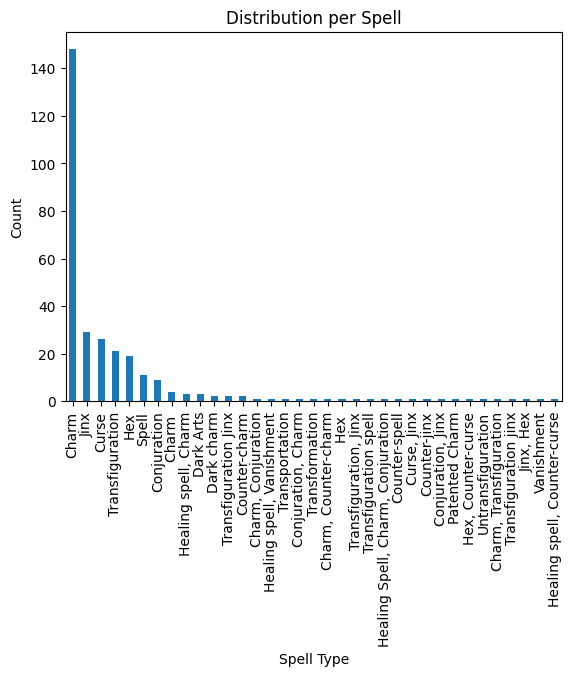

In [28]:
# Distribution per Spell

spells["Type"].value_counts().plot(kind="bar")
plt.title("Distribution per Spell")
plt.xlabel("Spell Type")
plt.ylabel("Count")
plt.show()

In [29]:
# Amount of times that each spell is said in the sentences dataset

valid_spells = spells['Incantation'].dropna().unique()
valid_spells = [s for s in valid_spells if s.strip() != '' and s.lower() != 'unknown']

# Calculate counts using a list comprehension with vectorized str.contains
spell_counts = [
    {'Incantation': inc, 'TimesSaid': hp_all['Sentence'].str.contains(inc, case=False, na=False).sum()}
    for inc in valid_spells
]

spells_mentions_df = pd.DataFrame(spell_counts).sort_values('TimesSaid', ascending=False)
print('--- Top 10 Spells Mentioned in Books 1-3 ---')
print(spells_mentions_df.head(10))

--- Top 10 Spells Mentioned in Books 1-3 ---
            Incantation  TimesSaid
153          Riddikulus          8
55     Expecto Patronum          7
98                Lumos          5
56         Expelliarmus          5
3             Alohomora          4
181  Wingardium Leviosa          4
9         Arania Exumai          3
61               Finite          3
100        Lumos Maxima          3
123                Pack          3


In [30]:
# Filter spells that are said at least once
spells_said = spells_mentions_df[spells_mentions_df['TimesSaid'] > 0]

print(spells_said.head)

<bound method NDFrame.head of                Incantation  TimesSaid
153             Riddikulus          8
55        Expecto Patronum          7
98                   Lumos          5
56            Expelliarmus          5
3                Alohomora          4
181     Wingardium Leviosa          4
9            Arania Exumai          3
61                  Finite          3
100           Lumos Maxima          3
123                   Pack          3
173             Vera Verto          3
148                 Reparo          2
116          Oculus Reparo          2
114                    Nox          2
80               Immobulus          2
128     Petrificus Totalus          1
152            Rictusempra          1
127  Peskipiksi Pesternomi          1
2         Alarte Ascendare          1
17                Bombarda          1
19         Brackium Emendo          1
54           Everte Statum          1
26           Cistem Aperio          1
178        Vipera Evanesca          1
157           Serpen

C:\Users\manue\AppData\Local\Temp\ipykernel_24472\11940309.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faction_df.head(15), x='Faction', y='NumCharacters', palette='rocket')


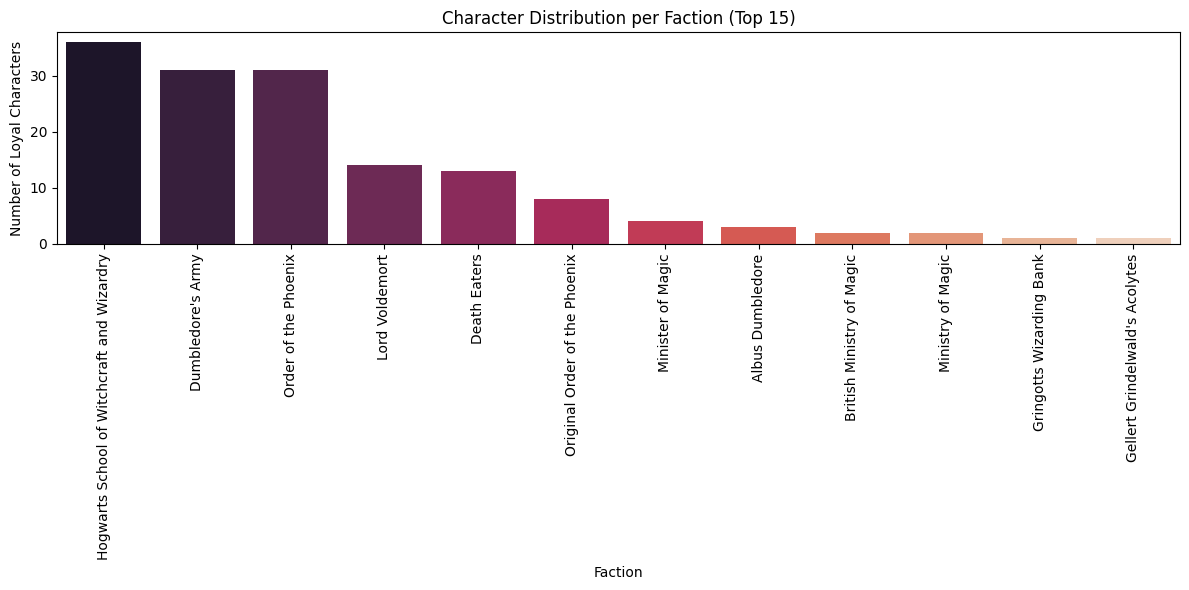

In [31]:
# Extract all factions from the Loyalty column

factions_series = characters['Loyalty'].dropna().str.split('|').explode().str.strip()
faction_df = factions_series.value_counts().reset_index()
faction_df.columns = ['Faction', 'NumCharacters']

# Visualization of Faction Loyalty
plt.figure(figsize=(12, 6))
sns.barplot(data=faction_df.head(15), x='Faction', y='NumCharacters', palette='rocket')
plt.xticks(rotation=90)
plt.title('Character Distribution per Faction (Top 15)')
plt.xlabel('Faction')
plt.ylabel('Number of Loyal Characters')
plt.tight_layout()
plt.show()

In [32]:
# Create a dataset with Character and Incantation if the Sentence contains an Incantation from spells_said (regardless of uppercase/lowercase letters)
rows = []
for _, row in hp_all.iterrows():
    for incantation in spells_said['Incantation']:
        if pd.notna(row['Sentence']) and pd.notna(incantation):
            if incantation.lower() in row['Sentence'].lower():
                rows.append({'Character': row['Character'], 'Incantation': incantation})
dataset_character_incantation = pd.DataFrame(rows)

print(dataset_character_incantation.head)

<bound method NDFrame.head of         Character       Incantation
0      OLLIVANDER            Finite
1   MOLLY WEASLEY              Pack
2          RONALD              Pack
3        HERMIONE            Reparo
4        HERMIONE     Oculus Reparo
..            ...               ...
61          LUPIN         Immobulus
62          HARRY  Expecto Patronum
63       HERMIONE          Bombarda
64          HARRY             Lumos
65          HARRY               Nox

[66 rows x 2 columns]>


In [33]:
# Create a dataset with Character and Incantation if the Sentence contains an Incantation from spells_said (regardless of uppercase/lowercase letters)
rows = []
for _, row in hp_all.iterrows():
    for incantation in spells_said['Incantation']:
        if pd.notna(row['Sentence']) and pd.notna(incantation):
            if incantation.lower() in row['Sentence'].lower():
                rows.append({'Character': row['Character'], 'Incantation': incantation})
dataset_character_incantation = pd.DataFrame(rows)

print(dataset_character_incantation.head)

<bound method NDFrame.head of         Character       Incantation
0      OLLIVANDER            Finite
1   MOLLY WEASLEY              Pack
2          RONALD              Pack
3        HERMIONE            Reparo
4        HERMIONE     Oculus Reparo
..            ...               ...
61          LUPIN         Immobulus
62          HARRY  Expecto Patronum
63       HERMIONE          Bombarda
64          HARRY             Lumos
65          HARRY               Nox

[66 rows x 2 columns]>


In [34]:
# Generate ‘Incantations’ column in characters
incantations_list = []
for _, char_row in characters.iterrows():
    name = str(char_row['Name'])
    # Search for all characters in dataset_character_incantation that are in Name (ignoring upper/lower case)
    incantations = dataset_character_incantation[
        dataset_character_incantation['Character'].apply(lambda c: c.lower() in name.lower())
    ]['Incantation'].unique()
    # Join the incantations with ‘ | ’ as in Loyalty, or leave blank if there are none
    incantations_str = ' | '.join(incantations) if len(incantations) > 0 else ''
    incantations_list.append(incantations_str)

# Add the column to the original DataFrame
characters['Incantations'] = incantations_list

print(characters[['Name', 'Incantations']].head(5))

                                      Name  \
0                       Harry James Potter   
1                    Ronald Bilius Weasley   
2                    Hermione Jean Granger   
3  Albus Percival Wulfric Brian Dumbledore   
4                            Rubeus Hagrid   

                                        Incantations  
0  Finite | Rictusempra | Wingardium Leviosa | Ar...  
1  Pack | Alohomora | Wingardium Leviosa | Vera V...  
2  Reparo | Oculus Reparo | Alohomora | Wingardiu...  
3                                                     
4                                                     
